**Deep Learning Assignment 4**

Write a program to implement the naïve Bayesian classifier for a sample training data set stored
as a .CSV file. Compute the accuracy of the classifier, considering few test data set

Missing values before cleaning:
 Survived     0
Pclass       0
Sex          0
Age         86
SibSp        0
Parch        0
Fare         1
Embarked     0
dtype: int64

Missing values after cleaning:
 Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64

Any NaN left in X? 0

Accuracy: 1.0

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        50
           1       1.00      1.00      1.00        34

    accuracy                           1.00        84
   macro avg       1.00      1.00      1.00        84
weighted avg       1.00      1.00      1.00        84



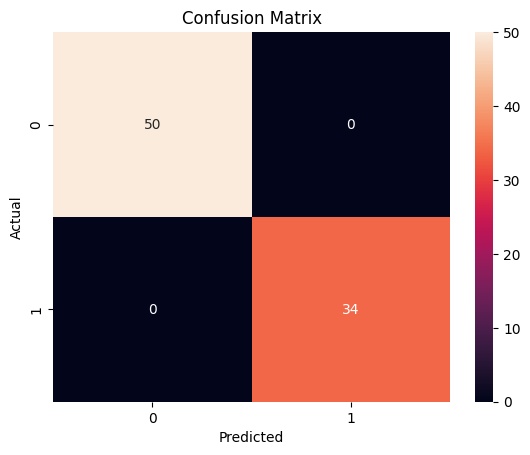

In [ ]:
# ----------------------------------
# 1. Import Libraries
# ----------------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer


# ----------------------------------
# 2. Load Dataset
# ----------------------------------
data = pd.read_csv("titanic.csv")

# ----------------------------------
# 3. Select Features
# ----------------------------------
data = data[['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']]

# ----------------------------------
# 4. Convert Categorical First
# ----------------------------------
le = LabelEncoder()
data['Sex'] = le.fit_transform(data['Sex'])

data['Embarked'] = data['Embarked'].astype(str)
data['Embarked'] = le.fit_transform(data['Embarked'])

# ----------------------------------
# 5. Handle Missing Values (ALL Columns)
# ----------------------------------

# Check missing values
print("Missing values before cleaning:\n", data.isnull().sum())

# Imputer for numeric columns
imputer = SimpleImputer(strategy='mean')
data[['Age', 'Fare']] = imputer.fit_transform(data[['Age', 'Fare']])

# Imputer for categorical (just in case)
data[['Embarked']] = SimpleImputer(strategy='most_frequent').fit_transform(data[['Embarked']])

# Final check
print("\nMissing values after cleaning:\n", data.isnull().sum())

# ----------------------------------
# 6. Define X and y
# ----------------------------------
X = data.drop('Survived', axis=1)
y = data['Survived']

# Final safety check
print("\nAny NaN left in X?", np.isnan(X).sum().sum())

# ----------------------------------
# 7. Train Test Split
# ----------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ----------------------------------
# 8. Train Model
# ----------------------------------
model = GaussianNB()
model.fit(X_train, y_train)

# ----------------------------------
# 9. Prediction
# ----------------------------------
y_pred = model.predict(X_test)

# ----------------------------------
# 10. Accuracy
# ----------------------------------
accuracy = accuracy_score(y_test, y_pred)
print("\nAccuracy:", accuracy)

print("\nClassification Report:\n", classification_report(y_test, y_pred))

# ----------------------------------
# 11. Confusion Matrix Visualization
# ----------------------------------
cm = confusion_matrix(y_test, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


Data preprocessing completed
Model trained successfully

Accuracy: 1.0

Classification Report:

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



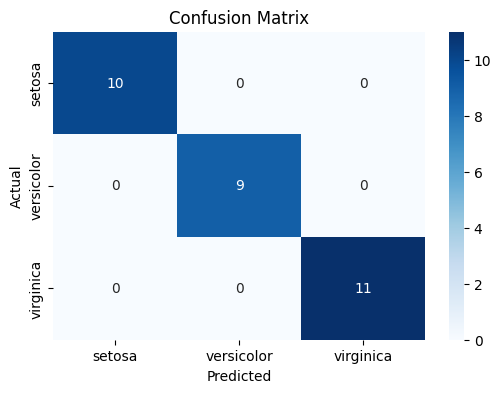


Correct Predictions:

Actual: versicolor | Predicted: versicolor
Actual: setosa | Predicted: setosa
Actual: virginica | Predicted: virginica
Actual: versicolor | Predicted: versicolor
Actual: versicolor | Predicted: versicolor
Actual: setosa | Predicted: setosa
Actual: versicolor | Predicted: versicolor
Actual: virginica | Predicted: virginica
Actual: versicolor | Predicted: versicolor
Actual: versicolor | Predicted: versicolor
Actual: virginica | Predicted: virginica
Actual: setosa | Predicted: setosa
Actual: setosa | Predicted: setosa
Actual: setosa | Predicted: setosa
Actual: setosa | Predicted: setosa
Actual: versicolor | Predicted: versicolor
Actual: virginica | Predicted: virginica
Actual: versicolor | Predicted: versicolor
Actual: versicolor | Predicted: versicolor
Actual: virginica | Predicted: virginica
Actual: setosa | Predicted: setosa
Actual: virginica | Predicted: virginica
Actual: setosa | Predicted: setosa
Actual: virginica | Predicted: virginica
Actual: virginica | Pre

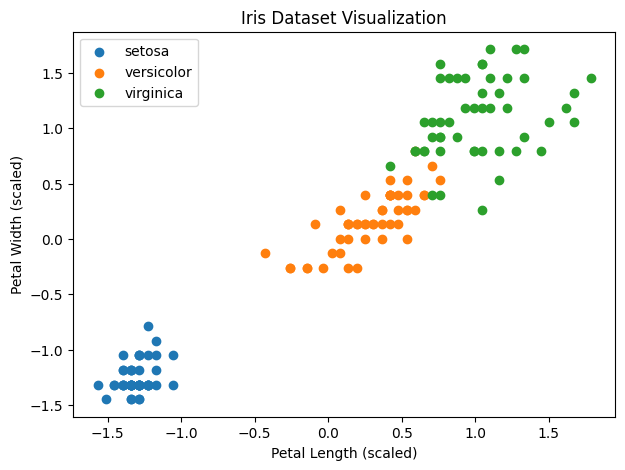

In [1]:
# ==========================================
# Assignment 4: Naive Bayes Classifier
# Dataset: Iris
# ==========================================

# ------------------------------------------
# 1. Import Libraries
# ------------------------------------------

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)
from sklearn.preprocessing import StandardScaler

# ------------------------------------------
# 2. Load Dataset
# ------------------------------------------

iris = load_iris()

X = iris.data
y = iris.target

feature_names = iris.feature_names
target_names = iris.target_names

# ------------------------------------------
# 3. Data Preprocessing
# ------------------------------------------

# Feature Scaling
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("Data preprocessing completed")

# ------------------------------------------
# 4. Train-Test Split
# ------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

# ------------------------------------------
# 5. Train Gaussian Naive Bayes Model
# ------------------------------------------

model = GaussianNB()

model.fit(X_train, y_train)

print("Model trained successfully")

# ------------------------------------------
# 6. Predictions
# ------------------------------------------

y_pred = model.predict(X_test)

# ------------------------------------------
# 7. Accuracy
# ------------------------------------------

accuracy = accuracy_score(y_test, y_pred)

print("\nAccuracy:", accuracy)

# ------------------------------------------
# 8. Classification Report
# ------------------------------------------

print("\nClassification Report:\n")

print(classification_report(
    y_test,
    y_pred,
    target_names=target_names
))

# ------------------------------------------
# 9. Confusion Matrix
# ------------------------------------------

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=target_names,
    yticklabels=target_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# ------------------------------------------
# 10. Correct and Wrong Predictions
# ------------------------------------------

print("\nCorrect Predictions:\n")

for i in range(len(y_test)):
    if y_test[i] == y_pred[i]:
        print(
            f"Actual: {target_names[y_test[i]]} "
            f"| Predicted: {target_names[y_pred[i]]}"
        )

print("\nWrong Predictions:\n")

wrong_found = False

for i in range(len(y_test)):
    if y_test[i] != y_pred[i]:

        wrong_found = True

        print(
            f"Actual: {target_names[y_test[i]]} "
            f"| Predicted: {target_names[y_pred[i]]}"
        )

if not wrong_found:
    print("No wrong predictions")

# ------------------------------------------
# 11. Visualization (Scatter Plot)
# ------------------------------------------

plt.figure(figsize=(7,5))

for class_value, color, label in zip(
    [0,1,2],
    ['red','green','blue'],
    target_names
):

    plt.scatter(
        X_scaled[y == class_value, 2],
        X_scaled[y == class_value, 3],
        label=label
    )

plt.xlabel("Petal Length (scaled)")
plt.ylabel("Petal Width (scaled)")
plt.title("Iris Dataset Visualization")
plt.legend()
plt.show()

Dataset Shape: (178, 13)

Data preprocessing completed

Model trained successfully

Accuracy: 1.0

Classification Report:

              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        14
     class_1       1.00      1.00      1.00        14
     class_2       1.00      1.00      1.00         8

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36



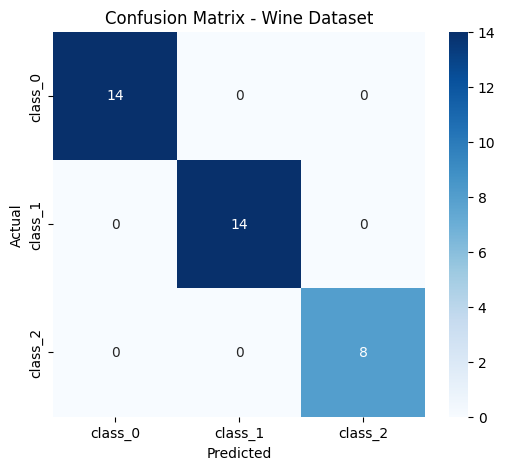


Correct Predictions:

Actual: class_0 | Predicted: class_0
Actual: class_0 | Predicted: class_0
Actual: class_2 | Predicted: class_2
Actual: class_0 | Predicted: class_0
Actual: class_1 | Predicted: class_1
Actual: class_0 | Predicted: class_0
Actual: class_1 | Predicted: class_1
Actual: class_2 | Predicted: class_2
Actual: class_1 | Predicted: class_1
Actual: class_2 | Predicted: class_2
Actual: class_0 | Predicted: class_0
Actual: class_2 | Predicted: class_2
Actual: class_0 | Predicted: class_0
Actual: class_1 | Predicted: class_1
Actual: class_0 | Predicted: class_0
Actual: class_1 | Predicted: class_1
Actual: class_1 | Predicted: class_1
Actual: class_1 | Predicted: class_1
Actual: class_0 | Predicted: class_0
Actual: class_1 | Predicted: class_1
Actual: class_0 | Predicted: class_0
Actual: class_1 | Predicted: class_1
Actual: class_1 | Predicted: class_1
Actual: class_2 | Predicted: class_2
Actual: class_2 | Predicted: class_2
Actual: class_2 | Predicted: class_2
Actual: class_1

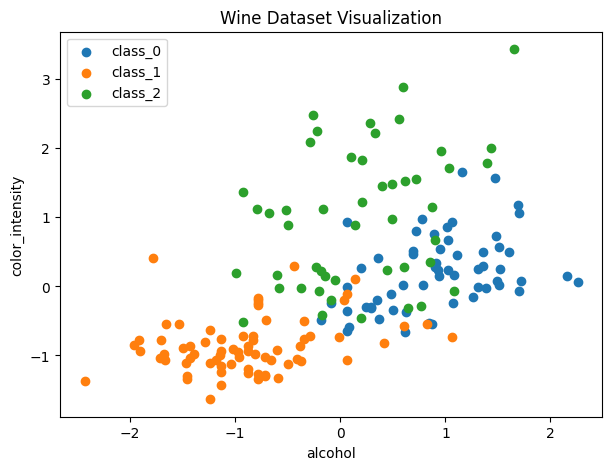

In [2]:
# ==========================================
# Assignment 4: Naive Bayes Classifier
# Dataset: Wine Dataset
# ==========================================

# ------------------------------------------
# 1. Import Libraries
# ------------------------------------------

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

# ------------------------------------------
# 2. Load Dataset
# ------------------------------------------

wine = load_wine()

X = wine.data
y = wine.target

feature_names = wine.feature_names
target_names = wine.target_names

print("Dataset Shape:", X.shape)

# ------------------------------------------
# 3. Data Preprocessing
# ------------------------------------------

# Feature Scaling
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("\nData preprocessing completed")

# ------------------------------------------
# 4. Train-Test Split
# ------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

# ------------------------------------------
# 5. Train Gaussian Naive Bayes Model
# ------------------------------------------

model = GaussianNB()

model.fit(X_train, y_train)

print("\nModel trained successfully")

# ------------------------------------------
# 6. Predictions
# ------------------------------------------

y_pred = model.predict(X_test)

# ------------------------------------------
# 7. Accuracy
# ------------------------------------------

accuracy = accuracy_score(y_test, y_pred)

print("\nAccuracy:", accuracy)

# ------------------------------------------
# 8. Classification Report
# ------------------------------------------

print("\nClassification Report:\n")

print(classification_report(
    y_test,
    y_pred,
    target_names=target_names
))

# ------------------------------------------
# 9. Confusion Matrix
# ------------------------------------------

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=target_names,
    yticklabels=target_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Wine Dataset")
plt.show()

# ------------------------------------------
# 10. Correct and Wrong Predictions
# ------------------------------------------

print("\nCorrect Predictions:\n")

for i in range(len(y_test)):
    if y_test[i] == y_pred[i]:

        print(
            f"Actual: {target_names[y_test[i]]} "
            f"| Predicted: {target_names[y_pred[i]]}"
        )

print("\nWrong Predictions:\n")

wrong_found = False

for i in range(len(y_test)):
    if y_test[i] != y_pred[i]:

        wrong_found = True

        print(
            f"Actual: {target_names[y_test[i]]} "
            f"| Predicted: {target_names[y_pred[i]]}"
        )

if not wrong_found:
    print("No wrong predictions")

# ------------------------------------------
# 11. Visualization
# ------------------------------------------

plt.figure(figsize=(7,5))

for class_value, color, label in zip(
    [0,1,2],
    ['red','green','blue'],
    target_names
):

    plt.scatter(
        X_scaled[y == class_value, 0],
        X_scaled[y == class_value, 9],
        label=label
    )

plt.xlabel(feature_names[0])
plt.ylabel(feature_names[9])

plt.title("Wine Dataset Visualization")
plt.legend()

plt.show()